# Landscape Metrics: Plots

Reads the tidied/metric CSVs exported by the R Objective 3 pipeline (`scripts/r/`, specifically
`03_landscape_metrics.R`'s fragmentation/connectivity metrics and correlation screen) from
`outputs/tables/`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import config

In [2]:
sns.set_theme(style="whitegrid")
config.PLOTS_DIR.mkdir(parents=True, exist_ok=True)

SITE_ORDER = [s["site_id"] for s in config.SITES]
SITE_LABELS = {s["site_id"]: s["site_name"] for s in config.SITES}

## Load tables

`landscape_connectivity_metrics_binary_natural_by_site_year_season.csv` is long-format (one row
per site/year/season-or-period/metric) period-composite rows (`baseline_2016_2018` etc.) carry
`year`/`season` as NA, seasonal per-year rows carry `period` as NA. Plots 1-5 below use the
seasonal rows only (`year` not null).
`landscape_metric_correlation_matrix.csv` is long-format pairwise correlations
(`Var1`/`Var2`/`Freq`) from `03_landscape_metrics.R`'s redundancy screen, computed across ALL
those seasonal + period observations pooled together.


In [3]:
binary_metrics = pd.read_csv(config.TABLES_DIR / "landscape_connectivity_metrics_binary_natural_by_site_year_season.csv")
correlation_matrix = pd.read_csv(config.TABLES_DIR / "landscape_metric_correlation_matrix.csv")

## Plots 1-5: Natural-habitat fragmentation/connectivity metric trends by site

Five of the six headline metrics `03_landscape_metrics.R` computed on the binary natural-habitat
raster (classes 1-3 vs. 4-6), per site/year/season, 2016-2025 wet/dry seasonal composites. Color = site,
line style = season. PLAND is a percentage of the
*classified* (non-NA) area within each site, not of the site's full nominal polygon area. See
`landscape_valid_pixel_coverage_by_site_year_season.csv` for that ratio per site/year/season.


In [10]:
def plot_landscape_metric_trend(metric: str, ylabel: str, filename: str) -> None:
    """Line plot of one binary natural-habitat landscape metric by site/season, 2016-2025."""
    sub = binary_metrics[(binary_metrics["metric"] == metric) & binary_metrics["year"].notna()].copy()
    sub["site_name"] = sub["site_id"].map(SITE_LABELS)
    sub["year"] = sub["year"].astype(int)

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.lineplot(
        data=sub,
        x="year",
        y="value",
        hue="site_name",
        hue_order=[SITE_LABELS[s] for s in SITE_ORDER],
        style="season",
        markers=True,
        dashes=True,
        ax=ax,
    )
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Natural-habitat {metric.upper()} by site")
    ax.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(config.PLOTS_DIR / filename, dpi=200, bbox_inches="tight")

### Plot 1: PLAND (% of classified area, natural)

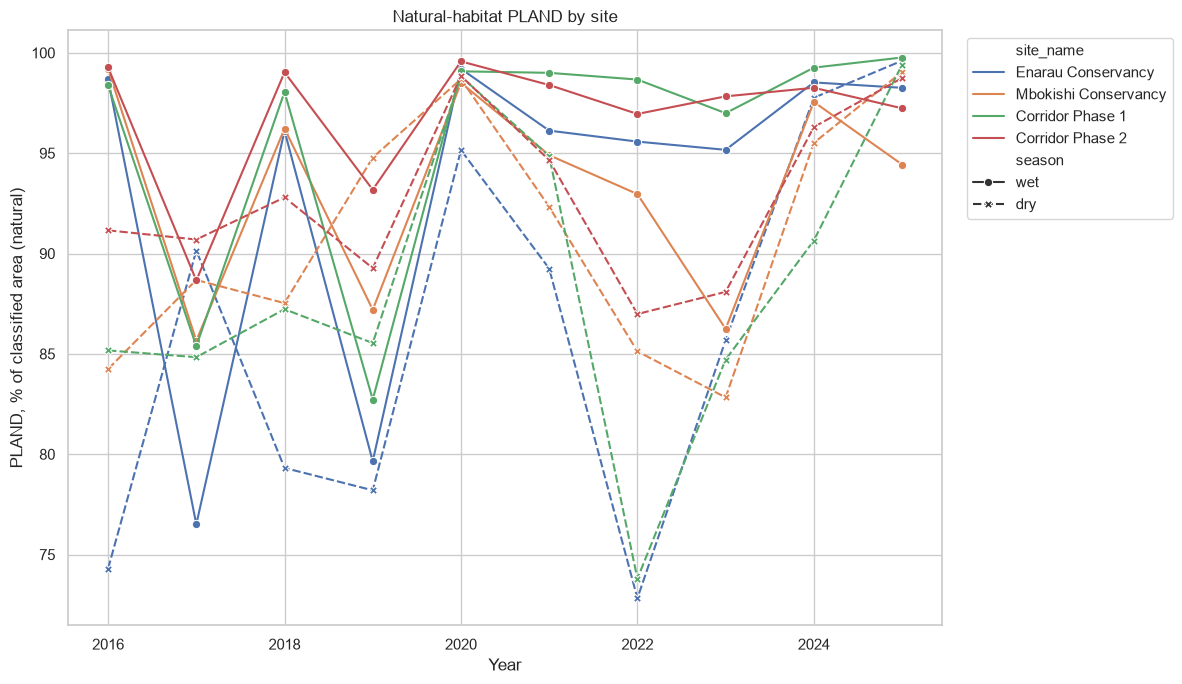

In [11]:
plot_landscape_metric_trend(
    "pland",
    "PLAND, % of classified area (natural)",
    "landscape_pland_by_site_trend.png",
)

### Plot 2: Patch density (PD)

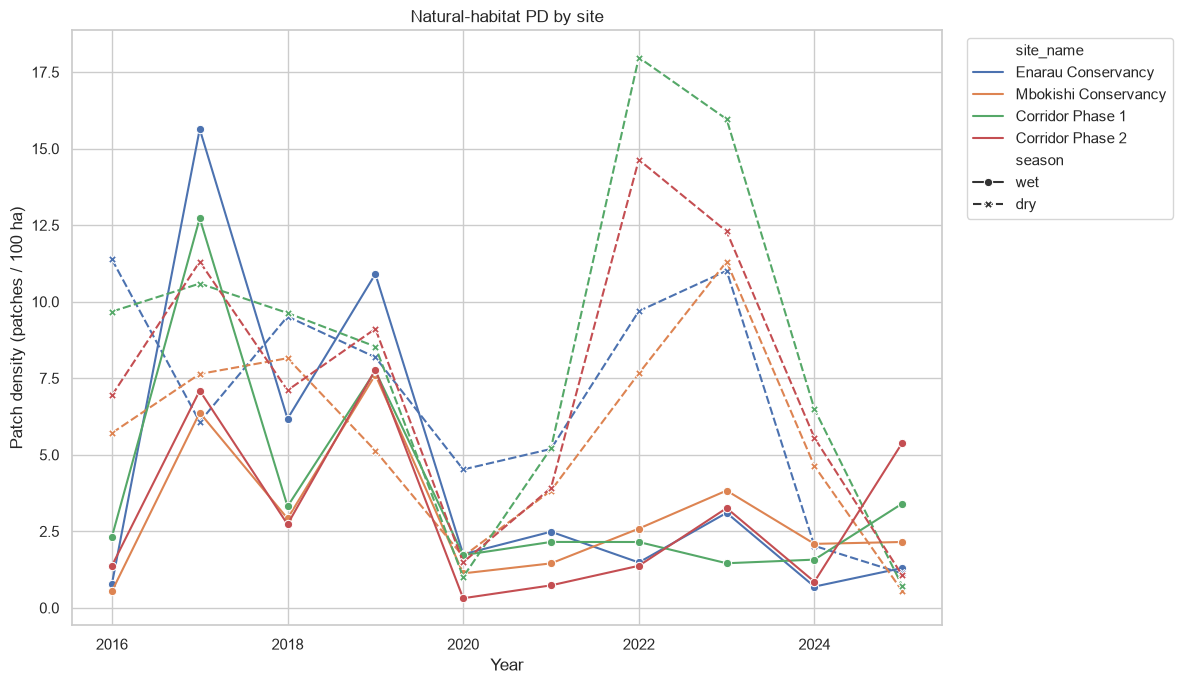

In [12]:
plot_landscape_metric_trend(
    "pd",
    "Patch density (patches / 100 ha)",
    "landscape_pd_by_site_trend.png",
)

### Plot 3: Largest patch index (LPI)

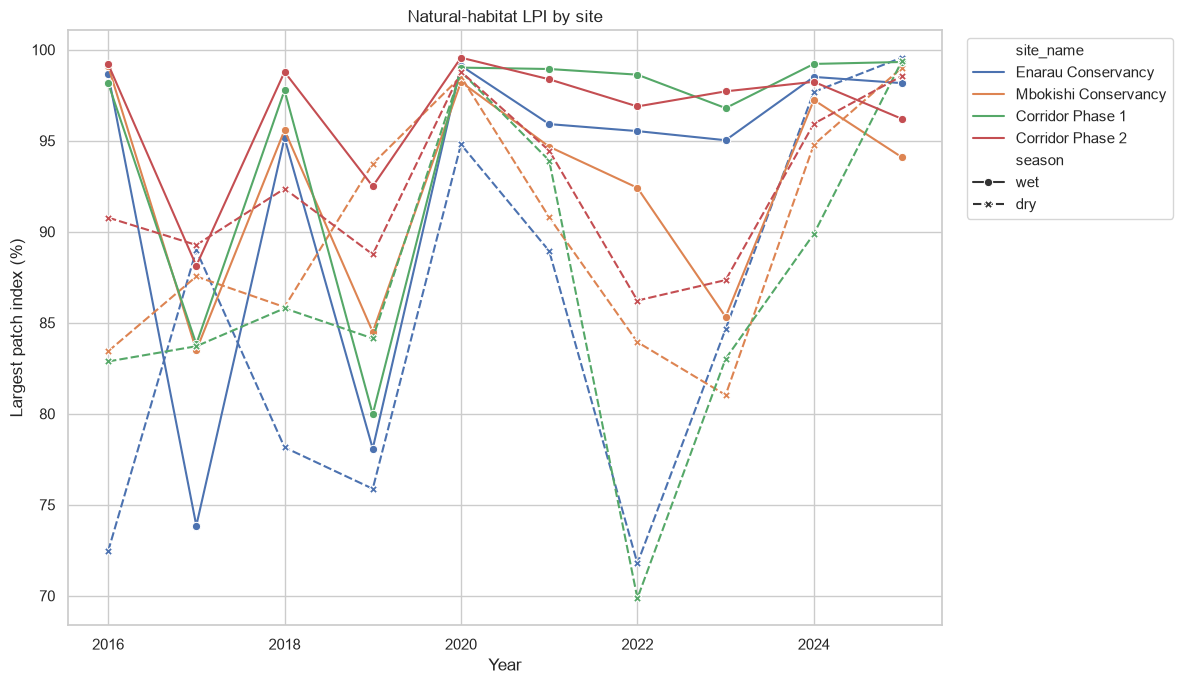

In [13]:
plot_landscape_metric_trend(
    "lpi",
    "Largest patch index (%)",
    "landscape_lpi_by_site_trend.png",
)

### Plot 4: Cohesion

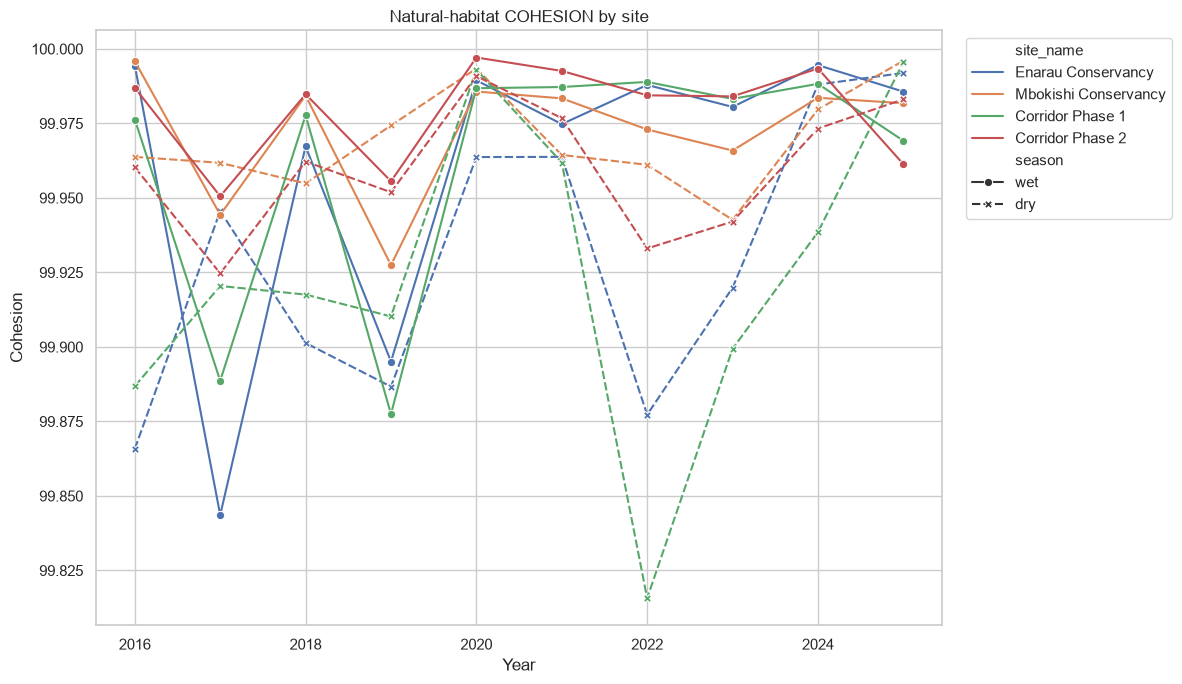

In [14]:
plot_landscape_metric_trend(
    "cohesion",
    "Cohesion",
    "landscape_cohesion_by_site_trend.png",
)

### Plot 5: Effective mesh size (MESH)

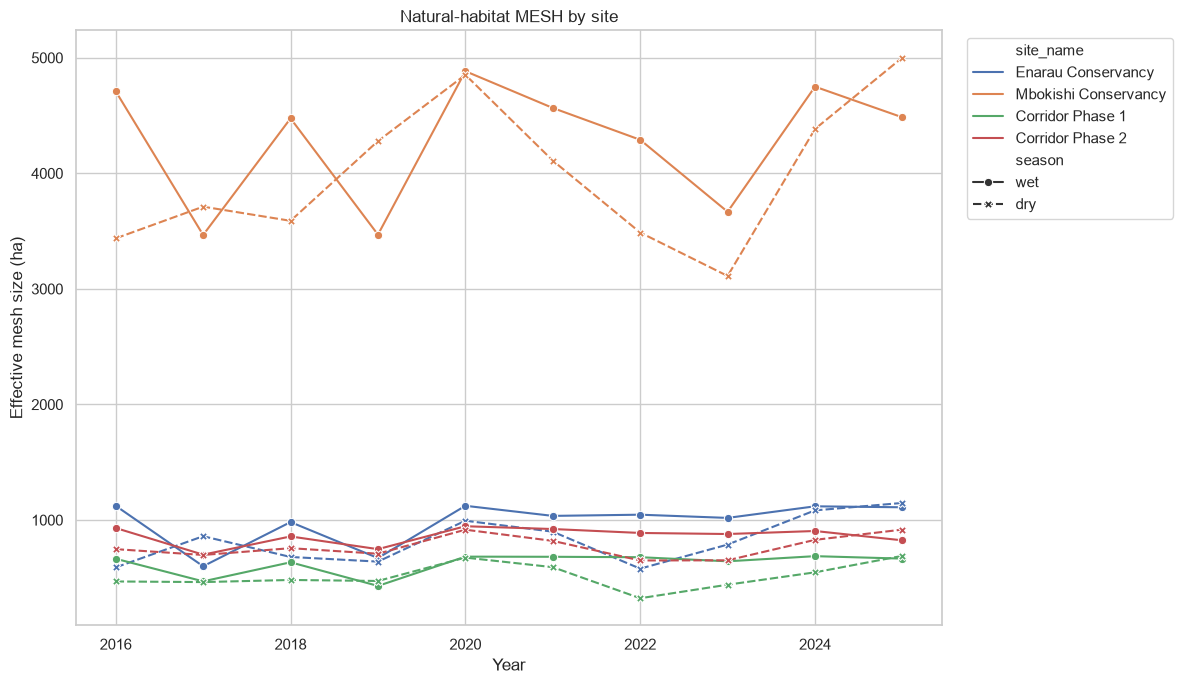

In [15]:
plot_landscape_metric_trend(
    "mesh",
    "Effective mesh size (ha)",
    "landscape_mesh_by_site_trend.png",
)

## Plot 6: Metric correlation matrix

Pairwise correlation (pooled across every site/year/season/period observation) among the nine
binary natural-habitat metrics (`ai`, `clumpy`, `cohesion`, `ed`, `enn_mn`, `lpi`, `mesh`, `pd`,
`pland`), from `03_landscape_metrics.R`'s redundancy screen -- the entropy pilot
(`landscape_entropy_pilot_by_site_year_season.csv`) is computed separately and not part of this
correlation matrix. Per the plan's own criterion, a pair with `|r| > 0.85` that "tells a similar
ecological story" should have one metric dropped from the final six-headline-metric reporting
set -- that's a human judgment call for the report, not something this notebook decides
automatically.


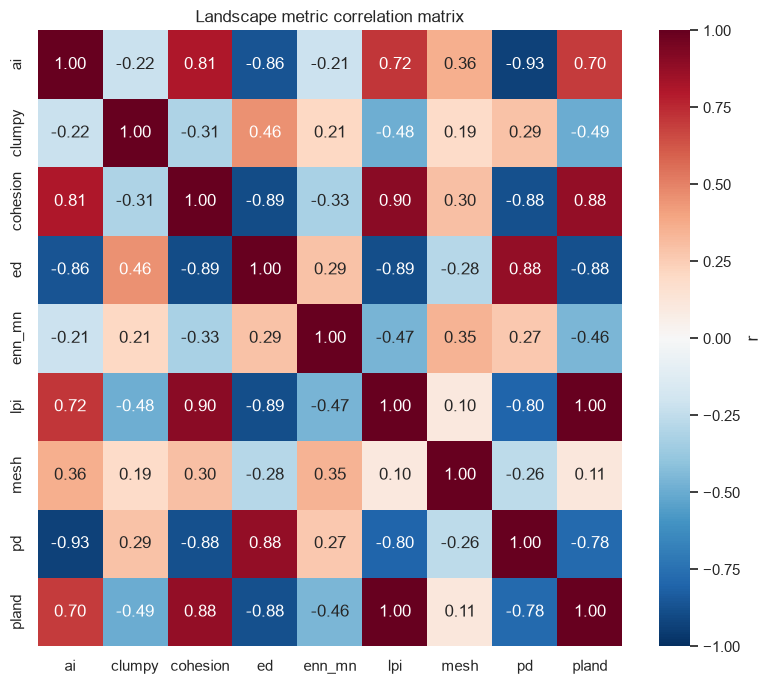

In [10]:
corr_wide = correlation_matrix.pivot(index="Var1", columns="Var2", values="Freq")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr_wide,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    cbar_kws={"label": "r"},
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Landscape metric correlation matrix")
fig.tight_layout()
fig.savefig(config.PLOTS_DIR / "landscape_metric_correlation_heatmap.png", dpi=200, bbox_inches="tight")

## Notes & next steps

- Patch-level and patch-graph outputs (`landscape_patch_metrics_current.csv`,
  `landscape_patch_importance_scores_current.csv`, `landscape_patch_graph_metrics_current.csv`,
  and the `outputs/vectors/*.gpkg` patch/graph/candidate-linkage-area files) are spatial/vector,
  not the kind of site/year trend or pairwise-correlation data this notebook charts -- view those
  in QGIS or similar rather than here.
- `landscape_metric_change_baseline_to_current.csv` / `..._pre_to_current.csv` (period-to-period
  deltas per site/metric) and `landscape_vs_objective2_crosscheck_by_site.csv` (the Mbokishi
  divergence caveat check) are tabular but small/summary in shape -- read directly rather than
  charted here; worth a simple bar chart in a future pass if the report needs one.
- Only seasonal (wet/dry per-year) rows are plotted in Plots 1-5; the same
  `landscape_connectivity_metrics_binary_natural_by_site_year_season.csv` also has period-composite
  rows (`year` is NA there) for baseline/pre/current period comparisons -- read those directly for
  period-level reporting rather than a per-year trend line.
